In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import brentq

BUDGET = 50_000

def research(x):
    """x is percentage points (0–100)"""
    if x <= 0:
        return 0.0
    return 200_000 * np.log(1 + x) / np.log(1 + 100)

def scale(x):
    """x is percentage points (0–100)"""
    return 7 * x / 100

def optimal_split(K):
    """
    Given K = remaining budget after speed allocation (in pct points),
    find r* that maximises research(r) * scale(K - r).

    FOC: (K - r) = (1 + r) * ln(1 + r)
    Solved numerically via Brent's method.
    """
    if K <= 0:
        return 0.0, 0.0
    # f(r) = 0  =>  r* is the optimum
    def f(r):
        return (K - r) - (1 + r) * np.log(1 + r)
    # f(0) = K > 0,  f(K) = -(1+K)*ln(1+K) < 0  => bracket always valid
    r_star = brentq(f, 0, K - 1e-9)
    c_star = K - r_star
    return r_star, c_star

def compute_pnl(speed_pct, speed_mult):
    K = 100 - speed_pct
    r, c = optimal_split(K)
    gross = research(r) * scale(c) * speed_mult
    net   = gross - BUDGET
    return net, r, c


In [3]:
speed_pcts = np.arange(0, 81, 1)          # 0 % … 80 % on speed
speed_mults = np.linspace(0.1, 0.9, 17)   # possible rank outcomes

PnL   = np.zeros((len(speed_mults), len(speed_pcts)))
R_opt = np.zeros_like(PnL)
C_opt = np.zeros_like(PnL)

for i, sm in enumerate(speed_mults):
    for j, sp in enumerate(speed_pcts):
        PnL[i, j], R_opt[i, j], C_opt[i, j] = compute_pnl(sp, sm)


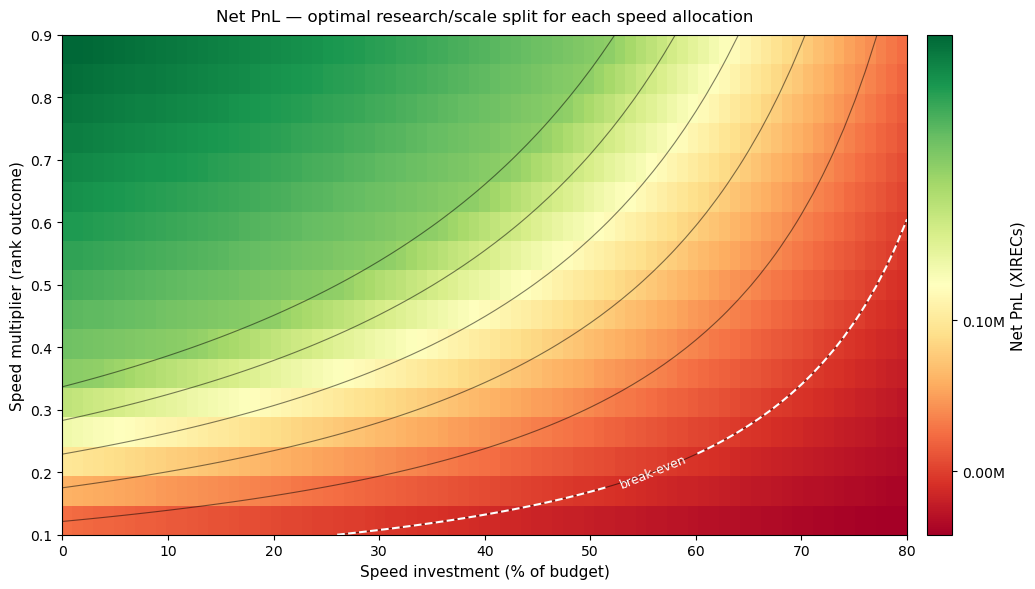

In [14]:
from matplotlib.colors import SymLogNorm

fig, ax = plt.subplots(figsize=(11, 6))

# tune this threshold — this is the key knob
linthresh = 200_000   # ~0.2M region gets high resolution

norm = SymLogNorm(
    linthresh=linthresh,
    linscale=1.0,
    vmin=PnL.min(),
    vmax=PnL.max(),
    base=10
)

im = ax.imshow(
    PnL,
    origin="lower",
    aspect="auto",
    extent=[speed_pcts[0], speed_pcts[-1],
            speed_mults[0], speed_mults[-1]],
    cmap="RdYlGn",
    norm=norm,
)

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("Net PnL (XIRECs)", fontsize=11)
cbar.ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e6:.2f}M")
)

# emphasize 0–0.2M region with contours
levels = np.linspace(0, 200_000, 6)
ax.contour(
    speed_pcts, speed_mults, PnL,
    levels=levels,
    colors="black",
    linewidths=0.8,
    alpha=0.5
)

# zero-PnL contour (keep prominent)
cs = ax.contour(
    speed_pcts, speed_mults, PnL,
    levels=[0], colors="white", linewidths=1.5, linestyles="--"
)
ax.clabel(cs, fmt="break-even", fontsize=9, colors="white")

ax.set_xlabel("Speed investment (% of budget)", fontsize=11)
ax.set_ylabel("Speed multiplier (rank outcome)", fontsize=11)
ax.set_title("Net PnL — optimal research/scale split for each speed allocation",
             fontsize=12, pad=10)

plt.tight_layout()
plt.show()

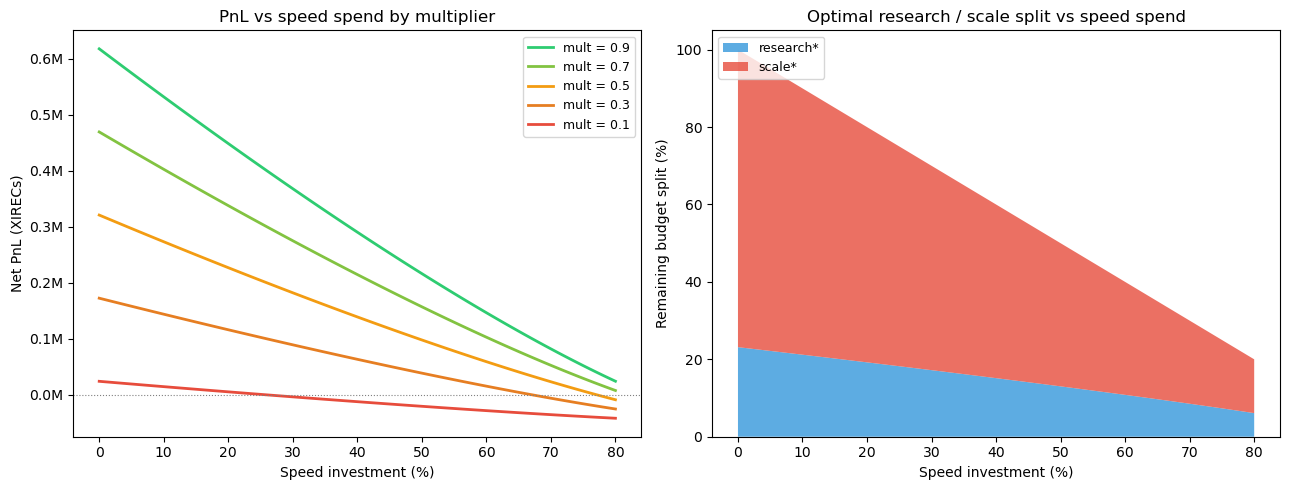

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

target_mults = [0.9, 0.7, 0.5, 0.3, 0.1]
colors = ["#2ecc71", "#82c341", "#f39c12", "#e67e22", "#e74c3c"]

# left: PnL vs speed spend for each multiplier scenario
ax = axes[0]
for sm, col in zip(target_mults, colors):
    pnls = [compute_pnl(sp, sm)[0] for sp in speed_pcts]
    ax.plot(speed_pcts, pnls, color=col, lw=2, label=f"mult = {sm:.1f}")
ax.axhline(0, color="gray", lw=0.8, ls=":")
ax.set_xlabel("Speed investment (%)")
ax.set_ylabel("Net PnL (XIRECs)")
ax.set_title("PnL vs speed spend by multiplier")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.legend(fontsize=9)

# right: optimal research vs scale split as speed varies (mult = 0.5)
ax2 = axes[1]
rs = [optimal_split(100 - sp)[0] for sp in speed_pcts]
cs_ = [optimal_split(100 - sp)[1] for sp in speed_pcts]
ax2.stackplot(speed_pcts, rs, cs_,
              labels=["research*", "scale*"],
              colors=["#3498db", "#e74c3c"], alpha=0.8)
ax2.set_xlabel("Speed investment (%)")
ax2.set_ylabel("Remaining budget split (%)")
ax2.set_title("Optimal research / scale split vs speed spend")
ax2.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()


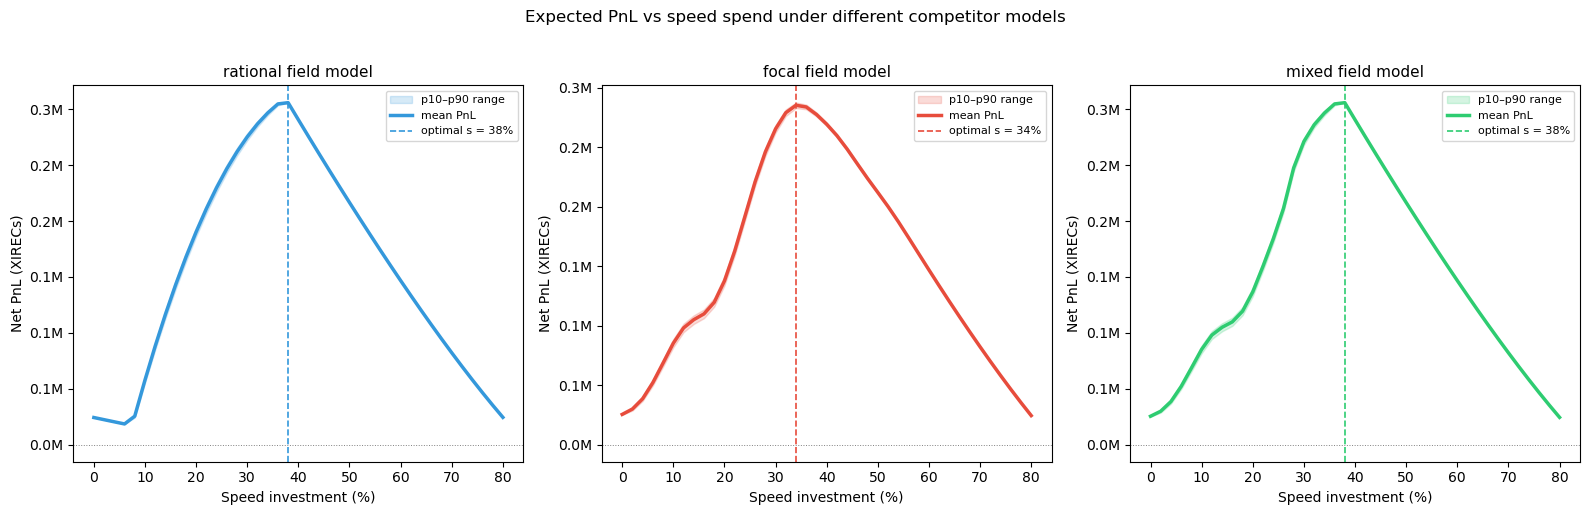

Model        Opt speed %    Expected PnL    
------------------------------------------
rational     38             305,894         
focal        34             285,078         
mixed        38             305,893         


In [11]:
import numpy as np
from scipy.optimize import brentq, minimize_scalar
from scipy.stats import beta, norm, truncnorm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── helpers from cell 1 ──────────────────────────────────────────────────────
def research(x):
    if x <= 0: return 0.0
    return 200_000 * np.log(1 + x) / np.log(101)

def scale(x):
    return 7 * x / 100

def optimal_split(K):
    if K <= 0: return 0.0, 0.0
    def f(r): return (K - r) - (1 + r) * np.log(1 + r)
    r_star = brentq(f, 0, K - 1e-9)
    return r_star, K - r_star

BUDGET = 50_000

# ── competitor speed distribution models ────────────────────────────────────
# We model the field's speed allocation (as % of budget, 0–100) under
# three qualitatively different assumptions about competitor behaviour.

N_COMPETITORS = 4500   # rough estimate of serious competitors; tweak this

def sample_competitors(model, n=N_COMPETITORS, size=10_000):
    """
    Returns array of shape (size, n): each row is one simulated field of n
    competitor speed allocations (in pct points, 0–100).
    model: 'rational' | 'focal' | 'mixed'
    """
    rng = np.random.default_rng(42)

    if model == 'rational':
        # Competitors estimate their own value and bid ~(n-k)/n of it.
        # Value of speed is uncertain; we model it as roughly uniform over
        # [10, 50] pct of budget, then they shade down by ~50% (top-50% rule).
        raw_values = rng.uniform(10, 50, size=(size, n))
        bids = raw_values * 0.75   # bid-shading: pay ~half of value
        return np.clip(bids, 0, 100)

    elif model == 'focal':
        # Many competitors anchor to round numbers / focal points.
        # Mix of people bidding ~0, ~25, ~33, ~50 on speed.
        choices = rng.choice([0, 5, 10, 20, 25, 30, 33, 40, 50],
                             p=[0.00, 0.08, 0.12, 0.17, 0.27, 0.16, 0.10, 0.06, 0.04],
                             size=(size, n))
        noise = rng.normal(0, 3, size=(size, n))
        return np.clip(choices + noise, 0, 100)

    elif model == 'mixed':
        # Blend: 60% focal, 40% rational
        focal = sample_competitors('focal', n, size)
        rational = sample_competitors('rational', n, size)
        mask = rng.random(size=(size, n)) < 0.6
        return np.where(mask, focal, rational)

# ── expected speed multiplier as function of your speed spend ────────────────
def expected_multiplier_curve(model, speed_grid=None, n=N_COMPETITORS, size=5_000):
    """
    For each speed spend s in speed_grid, compute the distribution of
    rank-based multipliers you'd receive against the simulated field.
    Returns (speed_grid, mean_mult, p10_mult, p90_mult)
    """
    if speed_grid is None:
        speed_grid = np.arange(0, 81, 2)

    field = sample_competitors(model, n=n, size=size)  # (size, n)

    mean_mults, p10_mults, p90_mults = [], [], []

    for s in speed_grid:
        # your bid is s; compare against each simulated field
        # rank: 1 = highest. equal bids share rank.
        my_bids = np.full(size, s)
        # how many competitors strictly beat you?
        beaten_by = (field > s).sum(axis=1)   # shape (size,)
        # how many tie with you (including yourself)?
        tied_with = (field == s).sum(axis=1) + 1  # +1 for you

        # rank = beaten_by + 1 (best case), beaten_by + tied_with (worst case)
        # use midpoint rank for tied groups (as per problem statement)
        my_rank = beaten_by + (tied_with + 1) / 2   # average rank in tied group
        total = n + 1  # n competitors + you

        # linear scale: rank 1 → 0.9, rank total → 0.1
        mult = 0.9 - (my_rank - 1) / (total - 1) * 0.8

        mean_mults.append(mult.mean())
        p10_mults.append(np.percentile(mult, 10))
        p90_mults.append(np.percentile(mult, 90))

    return speed_grid, np.array(mean_mults), np.array(p10_mults), np.array(p90_mults)

# ── expected PnL as function of speed spend ──────────────────────────────────
def expected_pnl_curve(model, speed_grid=None):
    if speed_grid is None:
        speed_grid = np.arange(0, 81, 2)
    sg, mean_m, p10_m, p90_m = expected_multiplier_curve(model, speed_grid)

    def pnl(s, mult):
        K = 100 - s
        r, c = optimal_split(K)
        return research(r) * scale(c) * mult - BUDGET

    mean_pnl = np.array([pnl(s, m) for s, m in zip(sg, mean_m)])
    p10_pnl  = np.array([pnl(s, m) for s, m in zip(sg, p10_m)])
    p90_pnl  = np.array([pnl(s, m) for s, m in zip(sg, p90_m)])

    opt_idx = np.argmax(mean_pnl)
    return sg, mean_pnl, p10_pnl, p90_pnl, sg[opt_idx], mean_pnl[opt_idx]

# ── plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models = ['rational', 'focal', 'mixed']
colors = {'rational': '#3498db', 'focal': '#e74c3c', 'mixed': '#2ecc71'}

for ax, model in zip(axes, models):
    sg, mean_pnl, p10_pnl, p90_pnl, opt_s, opt_pnl = expected_pnl_curve(model)

    ax.fill_between(sg, p10_pnl, p90_pnl, alpha=0.2, color=colors[model],
                    label='p10–p90 range')
    ax.plot(sg, mean_pnl, color=colors[model], lw=2.5, label='mean PnL')
    ax.axvline(opt_s, color=colors[model], lw=1.2, ls='--',
               label=f'optimal s = {opt_s}%')
    ax.axhline(0, color='gray', lw=0.7, ls=':')

    ax.set_title(f'{model} field model', fontsize=11)
    ax.set_xlabel('Speed investment (%)')
    ax.set_ylabel('Net PnL (XIRECs)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.legend(fontsize=8)

plt.suptitle('Expected PnL vs speed spend under different competitor models',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# ── print summary ─────────────────────────────────────────────────────────────
print(f"{'Model':<12} {'Opt speed %':<14} {'Expected PnL':<16}")
print("-" * 42)
for model in models:
    sg, mean_pnl, _, _, opt_s, opt_pnl = expected_pnl_curve(model)
    print(f"{model:<12} {opt_s:<14.0f} {opt_pnl:<16,.0f}")

In [27]:
def optimal_allocation(speed_pct, speed_mult=1.0, verbose=True):
    """
    Given a speed allocation (0–100%), compute:
    - optimal research allocation
    - optimal scale allocation
    - resulting PnL (for a given speed multiplier)

    Parameters
    ----------
    speed_pct : float
        % allocated to speed (0–100)
    speed_mult : float
        speed multiplier (rank outcome)
    verbose : bool
        whether to print results

    Returns
    -------
    dict with r, c, pnl
    """

    K = 100 - speed_pct  # remaining budget for research + scale

    if K <= 0:
        r, c = 0.0, 0.0
    else:
        r, c = optimal_split(K)

    gross = research(r) * scale(c) * speed_mult
    net = gross - BUDGET

    result = {
        "speed_pct": speed_pct,
        "research_pct": r,
        "scale_pct": c,
        "speed_mult": speed_mult,
        "PnL": net
    }

    if verbose:
        print(f"Speed allocation:   {speed_pct:.2f}%")
        print(f"Research allocation: {r:.2f}%")
        print(f"Scale allocation:    {c:.2f}%")
        print(f"Speed multiplier:    {speed_mult:.2f}")
        print(f"Net PnL:             {net:,.2f} XIRECs")

    return result

In [ ]:
optimal_allocation(speed_pct=42, speed_mult=0.4)



Speed allocation:   42.00%
Research allocation: 14.71%
Scale allocation:    43.29%
Speed multiplier:    0.40
Net PnL:             94,678.31 XIRECs


{'speed_pct': 42,
 'research_pct': 14.714203872952037,
 'scale_pct': 43.28579612704796,
 'speed_mult': 0.4,
 'PnL': np.float64(94678.30647242759)}

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def pnl_vs_speed_allocation(speed_mult):
    """
    For a fixed speed multiplier:
    - sweeps speed allocation (0–100%)
    - computes optimal research/scale split at each point
    - plots Net PnL vs speed allocation
    """

    speed_pcts = np.linspace(0, 100, 200)
    pnls = []
    r_opts = []
    c_opts = []

    for s in speed_pcts:
        K = 100 - s

        if K <= 0:
            r, c = 0.0, 0.0
        else:
            r, c = optimal_split(K)

        gross = research(r) * scale(c) * speed_mult
        net = gross - BUDGET

        pnls.append(net)
        r_opts.append(r)
        c_opts.append(c)

    pnls = np.array(pnls)

    # ---- plot ----
    plt.figure(figsize=(9, 5))
    plt.plot(speed_pcts, pnls)

    plt.axhline(0, linestyle="--", color="black", linewidth=1)

    plt.xlabel("Speed allocation (%)")
    plt.ylabel("Net PnL (XIRECs)")
    plt.title(f"PnL vs Speed Allocation (Speed multiplier = {speed_mult:.2f})")

    plt.tight_layout()
    plt.show()

    # ---- optional: return best point ----
    best_idx = np.argmax(pnls)

    print("=== Optimal Speed Allocation (given multiplier) ===")
    print(f"Speed:    {speed_pcts[best_idx]:.2f}%")
    print(f"Research: {r_opts[best_idx]:.2f}%")
    print(f"Scale:    {c_opts[best_idx]:.2f}%")
    print(f"PnL:      {pnls[best_idx]:,.2f}")

    return {
        "speed_pcts": speed_pcts,
        "pnls": pnls,
        "best_speed": speed_pcts[best_idx]
    }

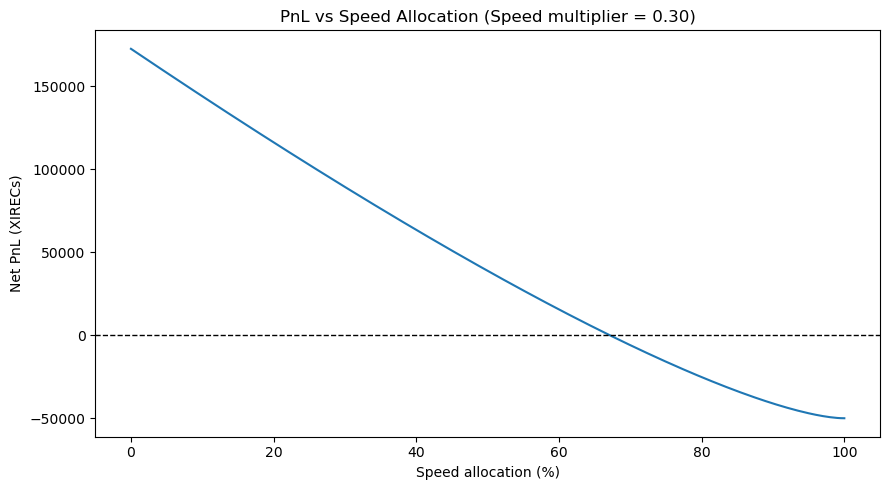

=== Optimal Speed Allocation (given multiplier) ===
Speed:    0.00%
Research: 23.14%
Scale:    76.86%
PnL:      172,700.90


{'speed_pcts': array([  0.        ,   0.50251256,   1.00502513,   1.50753769,
          2.01005025,   2.51256281,   3.01507538,   3.51758794,
          4.0201005 ,   4.52261307,   5.02512563,   5.52763819,
          6.03015075,   6.53266332,   7.03517588,   7.53768844,
          8.04020101,   8.54271357,   9.04522613,   9.54773869,
         10.05025126,  10.55276382,  11.05527638,  11.55778894,
         12.06030151,  12.56281407,  13.06532663,  13.5678392 ,
         14.07035176,  14.57286432,  15.07537688,  15.57788945,
         16.08040201,  16.58291457,  17.08542714,  17.5879397 ,
         18.09045226,  18.59296482,  19.09547739,  19.59798995,
         20.10050251,  20.60301508,  21.10552764,  21.6080402 ,
         22.11055276,  22.61306533,  23.11557789,  23.61809045,
         24.12060302,  24.62311558,  25.12562814,  25.6281407 ,
         26.13065327,  26.63316583,  27.13567839,  27.63819095,
         28.14070352,  28.64321608,  29.14572864,  29.64824121,
         30.15075377,  30.

In [21]:
pnl_vs_speed_allocation(0.3)